In [2]:
import sys
sys.path.append("/home/annierosen16")  # add directory with func.py
import pandas as pd
from func import cal_buoyancy
from sklearn.metrics import mean_squared_error
import glob
import os
import re
import traceback
from scipy.interpolate import interp1d
import cartopy.crs as ccrs
import requests
import datetime
import metpy.calc as mpcalc
from metpy.units import units
from metpy.cbook import get_test_data
from metpy.plots import add_metpy_logo, SkewT
from scipy.interpolate import interp1d
from scipy.optimize import bisect
from scipy.stats import pearsonr
import numpy as np
import pickle
import numpy as np
import math
import pint
from pydoc import help
import xarray as xr
import netCDF4 as nc
import re
import matplotlib.pyplot as plt
from numpy import load
from numpy import asarray
from numpy import save
import pytz
from scipy import stats
from sklearn.linear_model import LinearRegression
from collections import Counter
import pymannkendall as mk
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline

#### note to self: you can run all the commented code to calculate boundary layer humidity again or you can read back in the arrays that i saved further down 

In [3]:
# # reading in ERA5 specific humidity files 

# base_path = '/data/rong4/Data/ERA5/3hourly/quvw_US'

# years = [str(year) for year in range(2001, 2019)]

# def get_files(folder, component):

#     files = glob.glob(os.path.join(base_path, folder, f"era5.{component}.*.nc"))

#     filtered_files = [f for f in files if any(year in f for year in years)]
    
#     return filtered_files

# q_files = get_files('specific_humidity', 'specific_humidity')

# qdf = xr.open_mfdataset(q_files, combine='by_coords', chunks={'time': 24})

# qdf = qdf.sel(
    
#     latitude=slice(39, 30),
    
#     longitude=slice(-105, -95)
# )

# qdf['time'] = qdf['time'] - pd.Timedelta(hours=6)

# qdf = qdf.where(
    
#     (qdf.time.dt.month.isin([5, 6, 7, 8, 9])) &
    
#     (qdf.time.dt.year.isin(range(2001, 2019))),
    
#     drop=True
# )

# qdf = qdf.sel(time = qdf.time[qdf.time.dt.hour == 9])

KeyboardInterrupt: 

In [ ]:
# # reading in ERA5 geopotential height & temperature

# tz_path = '/home/annierosen16/data/era5sgp/era5_ml_t_geopotential_full_sgp'

# file_pattern = f"{tz_path}/ERA5_*_geopotential_temperature_profiles.nc"

# file_list = glob.glob(file_pattern)

# all_tz = xr.open_mfdataset(file_list, combine='by_coords')

# #, chunks={'time': 24}

# # all_tz = all_tz.sel(pressure_level=(all_tz.pressure_level >= 450) & (all_tz.pressure_level <= 1000))

# all_tz = all_tz.assign_coords(valid_time=all_tz.valid_time - pd.Timedelta(hours=6))

# tzdf = all_tz.sel(valid_time=all_tz.valid_time[all_tz.valid_time.dt.hour == 9])

# tzdf['valid_time'].shape, tzdf['pressure_level'].data.shape

In [ ]:
# # ERA5 information: surface pressure

# sfc_pressure_path = '/data/rong4/Data/ERA5/3hourly/quvw_US/surface_pressure'

# all_files = glob.glob(os.path.join(sfc_pressure_path, "era5.surface_pressure.*.nc"))

# # Filter files for years 2001-2018 and months 5-9

# filtered_files = [
    
#     file for file in all_files 
    
#     if 2001 <= int(os.path.basename(file).split(".")[2][:4]) <= 2018  
    
#     and 5 <= int(os.path.basename(file).split(".")[2][4:]) <= 9       
# ]

# all_sfc_p = xr.open_mfdataset(filtered_files, combine='by_coords')

# all_sfc_p = all_sfc_p.sel(latitude=slice(39.0, 30.0), longitude=slice(-105.0, -95.0))

# sfcp = all_sfc_p.assign_coords(time=all_sfc_p.time - pd.Timedelta(hours=6))

# sfcp = sfcp.sel(time=sfcp.time[sfcp.time.dt.hour == 9])

# sfcp['time'].shape

In [ ]:
# # loading all necessary information for buoyancy 

# g = 9.80665 # m/s^2

# # 1 dimensional

# times = qdf['time'].data

# # 3 dimensional (time, lat, lon)

# sp = sfcp['sp'].load().data / 100 # conversion to hPa

# # 4 dimensional (time, pressure, lat, lon)

# q = qdf['q'].load().data * 1000 # conversion to g/kg

# # 4 dimensional (time, pressure - reversed to go from bottom to top -, lat, lon)

# t = tzdf['t'].load().data[:, :, :, :] - 273.15 # conversion to Celsius

# # 4 dimensional (time, pressure, lat, lon)

# z = tzdf['z'].load().data[:, :, :, :] / g 

# lats = tzdf['latitude'].data

# lons = tzdf['longitude'].data

In [ ]:
# # step 1 -> interpolate pressure to altitude

# def interpolate_pressure_to_altitude(pres_array, alt_array, surface_pressure):
    
#     x = alt_array
    
#     y = pres_array

#     f = interp1d(x, y, assume_sorted=False, fill_value="extrapolate")

#     max_x = np.nanmax(x)
    
#     min_x = np.nanmin(x)

#     xint = np.arange(min_x, max_x, 20)

#     # Interpolate pressure against new altitude intervals
    
#     yint = f(xint) * units.hPa
    
#     yint = yint.magnitude  # Extract numerical values

#     # Compute altitude above surface
    
#     mask = yint <= surface_pressure
    
#     xnew = xint[mask]
    
#     ynew = yint[mask]

#     if xnew.size == 0:
        
#         return np.array([]), np.array([]), np.nan 

#     sfc_alt = xnew[0]  # Define surface altitude before adjusting xnew
    
#     xnew_rel = xnew - sfc_alt

#     # Apply single mask to keep values within 5000m AGL
    
#     valid_mask = xnew_rel <= 4000 # meters AGL
    
#     xclean = xnew_rel[valid_mask]
    
#     if xclean[-1] != 4000:
        
#         print(xclean[-1])
    
#     yclean = ynew[valid_mask]

#     return yclean, sfc_alt

In [87]:
# # for all days (at 9 LST), latitudes & longitudes: interpolate pressure 

# num_levels = 201 # equivalent to 4000 meters AGL for every gridpoint

# num_times = times.shape[0]

# # from bottom to top 

# pres_array = tzdf['pressure_level'].data

# interpolated_pressure = np.full((num_times, num_levels, lats.shape[0], lons.shape[0]), np.nan)

# # surface_altitudes captures geopotential height at the surface for all times and gridpoints

# surface_altitudes = np.full((num_times, lats.shape[0], lons.shape[0]), np.nan)

# for tidx in range(times.shape[0]):
    
#     for latidx in range(lats.shape[0]):

#         for lonidx in range(lons.shape[0]):

#             alt_array = z[tidx, :, latidx, lonidx]
            
#             alt_array_cut = alt_array[:pres_array.shape[0]]
        
#             sfc_pres = sp[tidx, latidx, lonidx]
            
#             new_pres, sfc_alt = interpolate_pressure_to_altitude(pres_array, alt_array_cut, sfc_pres)

#             interpolated_pressure[tidx, :, latidx, lonidx] = new_pres

#             surface_altitudes[tidx, latidx, lonidx] = sfc_alt

In [89]:
# # cleaner version

# def interpolate_var_to_altitude(variable_to_interpolate, alt_array, sfc_alt):
    
#     x = alt_array
    
#     y = variable_to_interpolate

#     f = interp1d(x, y, assume_sorted=False, fill_value="extrapolate")

#     max_x = np.nanmax(x)
    
#     min_x = np.nanmin(x)

#     xnew = np.arange(min_x, max_x, 20)
    
#     ynew = f(xnew)

#     # Compute relative altitude
    
#     xnew_rel = xnew - sfc_alt
    
#     valid_mask = np.logical_and(xnew_rel >= 0, xnew_rel <= 4000)

#     yfinal = ynew[valid_mask]
    
#     xfinal = xnew_rel[valid_mask]

#     return yfinal

In [110]:
# # interpolation of specific humidity 

# num_levels = 201 # equivalent to 4000 meters AGL for every gridpoint

# num_times = times.shape[0]

# interpolated_q = np.full((num_times, num_levels, lats.shape[0], lons.shape[0]), np.nan)

# for tidx in range(times.shape[0]):
    
#     for latidx in range(lats.shape[0]):

#         for lonidx in range(lons.shape[0]):
            
#             q_array = q[tidx, ::-1, latidx, lonidx]
            
#             alt_array = z[tidx, :, latidx, lonidx]
            
#             q_array_cut = q_array[:alt_array.shape[0]]
            
#             sfc_alt = surface_altitudes[tidx, latidx, lonidx]

#             new_q = interpolate_var_to_altitude(q_array_cut, alt_array, sfc_alt)

#             interpolated_q[tidx, :, latidx, lonidx] = new_q

In [118]:
# interpolated_altitudes = np.arange(0, 4000 + 20, 20)

# bottom_1km_idx = interpolated_altitudes <= 1000
        
# bottom_2km_idx = interpolated_altitudes <= 2000

# bottom_1km_q = np.mean(interpolated_q[:, bottom_1km_idx, :, :], axis=1)

# bottom_2km_q = np.mean(interpolated_q[:, bottom_2km_idx, :, :], axis=1)

In [139]:
# ## arrays to create xarray dataset: lats, lons, times, bottom_1km_q, bottom_2km_q

# ml_q_9am = xr.Dataset(
    
#     {
#         "bottom_1km_q": (("time", "lat", "lon"), bottom_1km_q),
        
#         "bottom_2km_q": (("time", "lat", "lon"), bottom_2km_q)},
    
#     coords={
        
#         "time": times,
        
#         "lat": lats,
        
#         "lon": lons,
#     },
# )

In [142]:
# # Expand ~ to full home directory path

# out_dir = os.path.expanduser("~/backup_data")

# os.makedirs(out_dir, exist_ok=True)  # make sure directory exists

# out_file = os.path.join(out_dir, "ml_q_9am.nc")

# ml_q_9am.to_netcdf(out_file)

# print(f"Saved dataset to: {out_file}")

Saved dataset to: /home/annierosen16/backup_data/ml_q_9am.nc


In [29]:
# ## reading it back in 

# out_file = os.path.expanduser("~/backup_data/ml_q_9am.nc")

# #low level q

# llq = xr.open_dataset(out_file)

In [3]:
# load interpolated q for 12 LST

backup_dir = os.path.expanduser("~/backup_data")

file_path = os.path.join(backup_dir, "backup_arrays_for_buoyancy.npz")  # Full path to save file

data = np.load(file_path)  # Load the .npz file

interpolated_q = data['array2']

interpolated_qfit = data['array_4']

print("interpolated_pressure loaded")

print("interpolated_qfit loaded")

interpolated_pressure loaded
interpolated_qfit loaded


### are qR - qLC and qLC correlated? 

In [4]:
# convert to xarray DataArrays

time = np.arange(interpolated_q.shape[0])

level = np.arange(interpolated_q.shape[1])

lat = np.arange(interpolated_q.shape[2])

lon = np.arange(interpolated_q.shape[3])

qr = xr.DataArray(interpolated_q, dims=["time", "level", "lat", "lon"],
                 coords={"time": time, "level": level, "lat": lat, "lon": lon})

qfit = xr.DataArray(interpolated_qfit, dims=["time", "level", "lat", "lon"],
                    coords={"time": time, "level": level, "lat": lat, "lon": lon})

interpolated_altitudes = np.arange(0, 4000 + 20, 20)

# Define your mask for 2000–4000 m

# Replace 'level' coordinate with altitude values
qr = qr.assign_coords(level=interpolated_altitudes)

qfit = qfit.assign_coords(level=interpolated_altitudes)

mask = (interpolated_altitudes >= 2000) & (interpolated_altitudes <= 4000)

# Apply the mask to both DataArrays along the 'level' dimension

qr_subset = qr.sel(level=interpolated_altitudes[mask])

qfit_subset = qfit.sel(level=interpolated_altitudes[mask])

# residual

resid_subset = qr_subset - qfit_subset 

# compute correlation between residual and q fit at each gridpoint

corr = xr.corr(resid_subset, qfit_subset, dim="time")

In [5]:
backup_dir = os.path.expanduser("~/backup_data")

file_path = os.path.join(backup_dir, "backup_metadata_for_buoyancy.npz")

# Load lats and lons

data = np.load(file_path)

lats = data["lats"]

lons = data["lons"]

In [6]:
corr_mean = corr.mean(dim="level")

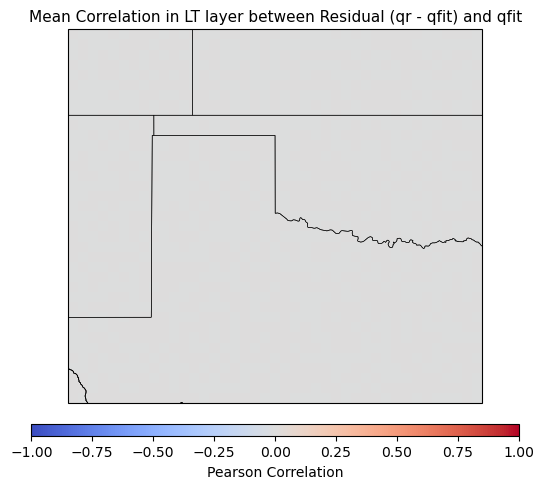

In [7]:
# Create figure and axis

fig = plt.figure(figsize=(8, 5))

ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features

ax.coastlines(resolution="50m", linewidth=1)

ax.add_feature(cfeature.BORDERS, linewidth=0.5)

ax.add_feature(cfeature.STATES, linewidth=0.4)

# Plot data

pcm = ax.pcolormesh(lons, lats, corr_mean, cmap="coolwarm", vmin=-1, vmax=1, transform=ccrs.PlateCarree())

# Colorbar

cb = plt.colorbar(pcm, ax=ax, orientation="horizontal", pad=0.05, aspect=40, fraction=0.03)

cb.set_label("Pearson Correlation")

# Title and layout

ax.set_title("Mean Correlation in LT layer between Residual (qr - qfit) and qfit", fontsize=11)

plt.tight_layout()

plt.show()

In [9]:
with open('/home/annierosen16/master_with_vt.pkl', 'rb') as f:
    
    master = pickle.load(f)
    
master["date"] = pd.to_datetime(master["date"]).dt.date

In [31]:
# ## compare master blt/blc data and 9am_ml_q

# llq = llq[["bottom_1km_q", "bottom_2km_q"]].to_dataframe().reset_index()

# llq = bottom_1km_df.rename(columns={"lat": "latitude", "lon": "longitude"})

# llq["date"] = pd.to_datetime(llq["time"]).dt.date

# llq = master.merge(
    
#     llq[["date", "latitude", "longitude", "bottom_1km_q", "bottom_2km_q"]],
    
#     on=["date", "latitude", "longitude"],
    
#     how="inner"
# )

In [21]:
df = master[["blt", "blc", "br", "dryape", "wetape", "latitude", "longitude"]].copy()

df = df.dropna()

df = df[np.isfinite(df["blt"]) & np.isfinite(df["blc"])]

r, p = pearsonr(df["blt"], df["blc"])

r, p

(-0.008400288562333694, 4.447537076590818e-66)

In [22]:
# Dry APE case

dry = master[master["dryape"] == True]

r_dry, p_dry = pearsonr(dry["blt"], dry["blc"])

# Wet APE case

wet = master[master["wetape"] == True]

r_wet, p_wet = pearsonr(wet["blt"], wet["blc"])

print(f"DryAPE: r = {r_dry:.3f}, p = {p_dry:.3e}")

print("")

print(f"WetAPE: r = {r_wet:.3f}, p = {p_wet:.3e}")

DryAPE: r = 0.181, p = 0.000e+00

WetAPE: r = -0.202, p = 0.000e+00


Number of significant correlations (dry, blc_stnd_anom vs blt_stnd_anom): 442


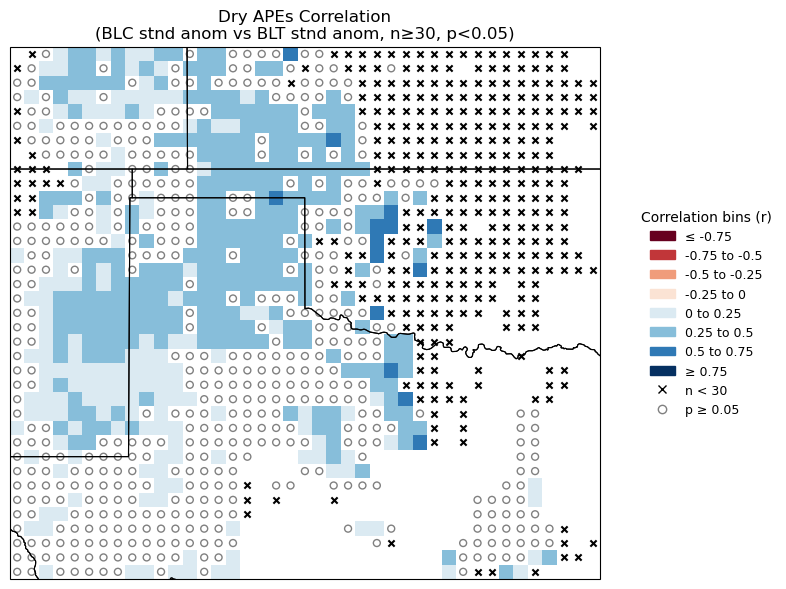

In [24]:
# --- User settings ---

dataset_type = "dry"           # or "wet"

var_x = "blc_stnd_anom"                  

var_y = "blt_stnd_anom"

datasets = {
    
    "dry": dry,
    
    "wet": wet,
    
    "master": master
}

data = datasets.get(dataset_type, master) 

# --- Map dataset_type to display name for title ---

title_map = {
    "dry": "Dry APEs",
    "wet": "Wet APEs",
    "master": "All Days"
}

title_dataset = title_map.get(dataset_type, dataset_type)

# --- Pretty display names for plotting ---
pretty_names = {
    "blc": "BLC",
    "blc_stnd_anom": "BLC stnd anom",
    "blt_stnd_anom": "BLT stnd anom",
    "blt": "BLT",
    "bottom_2km_q": "Bottom 2km q",
    "bottom_1km_q": "Bottom 1km q"
}

# --- Compute r and p per grid point ---

def corr_r_p(x):
    
    if len(x) < 30:
        
        return pd.Series([np.nan, np.nan], index=["r", "p"])
    
    r, p = pearsonr(x[var_x], x[var_y])
    
    return pd.Series([r, p], index=["r", "p"])

# corr = data.groupby(["latitude", "longitude"]).apply(corr_r_p).reset_index()

corr = data.groupby(["latitude", "longitude"]).apply(corr_r_p, include_groups=False).reset_index()

# --- Mask non-significant correlations ---

corr["r_masked"] = corr["r"].where(corr["p"] < 0.05)

print(f"Number of significant correlations ({dataset_type}, {var_x} vs {var_y}):",
      
      (corr["p"] < 0.05).sum())

# --- Define discrete correlation bins ---
bins = [-1.0, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1.0]

labels = ["≤ -0.75", "-0.75 to -0.5", "-0.5 to -0.25", "-0.25 to 0", 
          "0 to 0.25", "0.25 to 0.5", "0.5 to 0.75", "≥ 0.75"]

corr["r_bin"] = pd.cut(corr["r_masked"], bins=bins, labels=labels, include_lowest=True)

# --- Pivot to 2D grid for plotting ---
grid_bin = corr.pivot(index="latitude", columns="longitude", values="r_bin")

# --- Convert bins to numeric indices for plotting ---
grid_bin_num = grid_bin.replace({label: i for i, label in enumerate(labels)}).astype(float)

# --- Discrete colormap and norm ---
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

cmap = ListedColormap(plt.cm.RdBu(np.linspace(0, 1, len(labels))))
norm = BoundaryNorm(range(len(labels) + 1), cmap.N)

# --- Plot with Cartopy ---
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": ccrs.PlateCarree()})

im = ax.pcolormesh(
    grid_bin_num.columns, grid_bin_num.index, grid_bin_num.values,
    cmap=cmap, norm=norm, transform=ccrs.PlateCarree()
)

ax.add_feature(cfeature.STATES, linewidth=0.8)
ax.coastlines(resolution="10m", linewidth=0.8)

# --- Create custom legend (placed outside the figure) ---
from matplotlib.patches import Patch
handles = [Patch(color=cmap(i / (len(labels)-1)), label=label) for i, label in enumerate(labels)]

# Put legend outside on the right
legend = ax.legend(
    handles=handles,
    title="Correlation bins (r)",
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    fontsize=9,
    frameon=False
)

# --- Professional title ---

title_x = pretty_names.get(var_x, var_x)

title_y = pretty_names.get(var_y, var_y)

plt.title(f"{dataset_type.capitalize()} APE Correlation Bins\n({title_x} vs {title_y}, n≥30, p<0.05)")

# Adjust layout so legend fits nicely
plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leave space for legend
# --- Overlay symbols for data quality ---
# 1️⃣ Get grid points with < 30 samples
sample_counts = data.groupby(["latitude", "longitude"]).size().reset_index(name="n")
corr = corr.merge(sample_counts, on=["latitude", "longitude"], how="left")

# 2️⃣ Markers for insufficient samples (< 30)
mask_few = corr["n"] < 30
ax.scatter(
    corr.loc[mask_few, "longitude"],
    corr.loc[mask_few, "latitude"],
    s=20,
    marker="x",
    color="black",
    transform=ccrs.PlateCarree(),
    label="n < 30"
)

# 3️⃣ Markers for non-significant correlations (p ≥ 0.05)
mask_nonsig = corr["p"] >= 0.05
ax.scatter(
    corr.loc[mask_nonsig, "longitude"],
    corr.loc[mask_nonsig, "latitude"],
    s=25,
    marker="o",
    facecolors="none",
    edgecolors="gray",
    linewidths=1,
    transform=ccrs.PlateCarree(),
    label="p ≥ 0.05"
)

# 4️⃣ Merge with existing legend (keep color bin legend + markers)
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

handles_bins = [Patch(color=cmap(i / (len(labels)-1)), label=label) for i, label in enumerate(labels)]
handles_symbols = [
    Line2D([0], [0], marker="x", color="black", linestyle="None", markersize=6, label="n < 30"),
    Line2D([0], [0], marker="o", color="gray", linestyle="None", markersize=6, markerfacecolor="none", label="p ≥ 0.05")
]

# Combine legends
handles_all = handles_bins + handles_symbols

legend = ax.legend(
    handles=handles_all,
    title="Correlation bins (r)",
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    fontsize=9,
    frameon=False
)

# --- Title and layout ---
title_x = pretty_names.get(var_x, var_x)
title_y = pretty_names.get(var_y, var_y)
plt.title(f"{title_dataset} Correlation\n({title_x} vs {title_y}, n≥30, p<0.05)")

plt.tight_layout(rect=[0, 0, 0.85, 1])

plt.show()

/tmp/ipykernel_70513/1310454273.py:94: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handles=handles + [Patch(color="none", label="n < 30", edgecolor="red")],


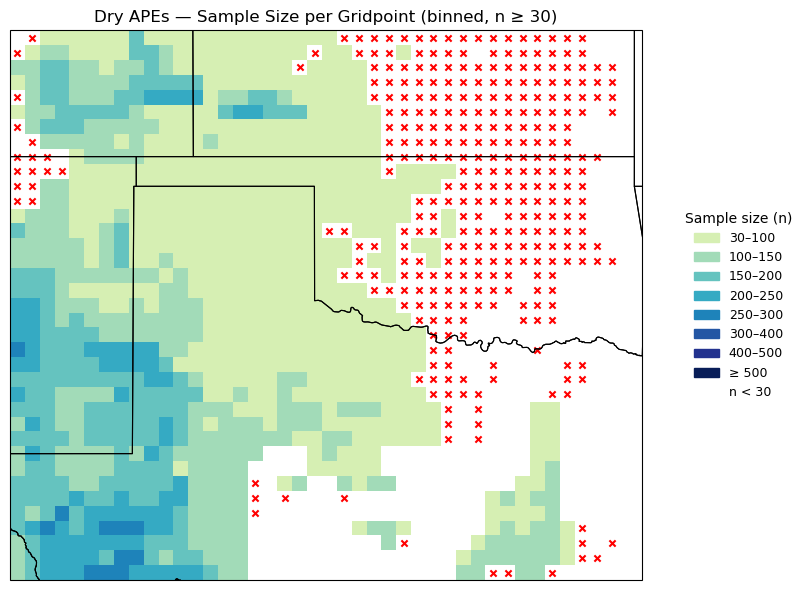

In [25]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# --- User settings ---
dataset_type = "dry"  # "dry", "wet", or "master"

# --- Define dataset dictionary ---
datasets = {
    "dry": dry,
    "wet": wet,
    "master": master
}

# --- Load dataset ---
data = datasets.get(dataset_type, master)

# --- Map dataset_type to title name ---
title_map = {
    "dry": "Dry APEs",
    "wet": "Wet APEs",
    "master": "All Days"
}
title_dataset = title_map.get(dataset_type, dataset_type)

# --- Compute sample size per gridpoint ---
sample_counts = (
    data.groupby(["latitude", "longitude"])
    .size()
    .reset_index(name="n")
)

# --- Keep only gridpoints with >= 30 samples ---
sample_counts_valid = sample_counts[sample_counts["n"] >= 30].copy()

# --- Define discrete bins for sample size ---
bins = [30, 100, 150, 200, 250, 300, 400, 500, np.inf]
labels = ["30–100", "100–150", "150–200", "200–250", "250–300", "300–400", "400–500", "≥ 500"]

# --- Assign bins ---
sample_counts_valid["n_bin"] = pd.cut(sample_counts_valid["n"], bins=bins, labels=labels, include_lowest=True)

# --- Pivot to 2D grid for plotting ---
grid_bin = sample_counts_valid.pivot(index="latitude", columns="longitude", values="n_bin")

# --- Convert bin labels to numeric indices for color mapping ---
grid_bin_num = grid_bin.replace({label: i for i, label in enumerate(labels)}).astype(float)

# --- Create discrete colormap ---
cmap = ListedColormap(plt.cm.YlGnBu(np.linspace(0.2, 1, len(labels))))
norm = BoundaryNorm(range(len(labels) + 1), cmap.N)

# --- Plot map ---
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": ccrs.PlateCarree()})

im = ax.pcolormesh(
    grid_bin_num.columns, grid_bin_num.index, grid_bin_num.values,
    cmap=cmap, norm=norm, shading="auto", transform=ccrs.PlateCarree()
)

# --- Add map features ---
ax.coastlines(resolution="10m", linewidth=0.8)
ax.add_feature(cfeature.STATES, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.6, linestyle="--")

# --- Custom legend (color-coded by bin) ---
handles = [Patch(color=cmap(i / (len(labels) - 1)), label=label) for i, label in enumerate(labels)]
ax.legend(
    handles=handles,
    title="Sample size (n)",
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    fontsize=9,
    frameon=False
)

# --- Optional: overlay points with n < 30 ---
sample_counts_few = sample_counts[sample_counts["n"] < 30]
ax.scatter(
    sample_counts_few["longitude"],
    sample_counts_few["latitude"],
    s=20, color="red", marker="x",
    transform=ccrs.PlateCarree(),
    label="n < 30"
)

# --- Add legend for n < 30 ---
ax.legend(
    handles=handles + [Patch(color="none", label="n < 30", edgecolor="red")],
    title="Sample size (n)",
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    fontsize=9,
    frameon=False
)

# --- Title ---
plt.title(f"{title_dataset} — Sample Size per Gridpoint (binned, n ≥ 30)")

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


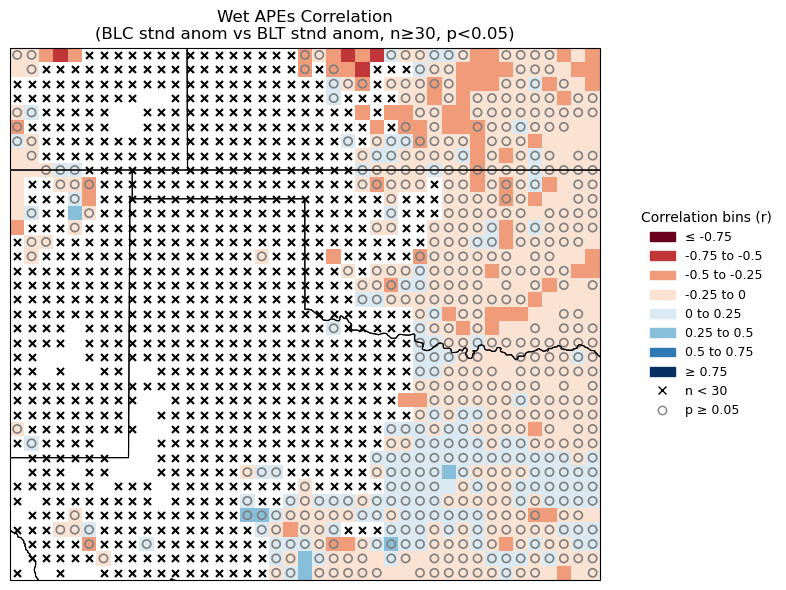

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- User settings ---
dataset_type = "wet"  # or "wet"
var_x = "blc_stnd_anom"
var_y = "blt_stnd_anom"

datasets = {"dry": dry, "wet": wet, "master": master}
data = datasets.get(dataset_type, master)

# --- Map dataset_type to display name for title ---
title_map = {"dry": "Dry APEs", "wet": "Wet APEs", "master": "All Days"}
title_dataset = title_map.get(dataset_type, dataset_type)

# --- Pretty variable names for plotting ---
pretty_names = {
    "blc": "BLC",
    "blc_stnd_anom": "BLC stnd anom",
    "blt_stnd_anom": "BLT stnd anom",
    "blt": "BLT",
    "bottom_2km_q": "Bottom 2km q",
    "bottom_1km_q": "Bottom 1km q",
}

# --- Compute correlation (r) and significance (p) per grid point ---
def corr_r_p(x):
    if len(x) < 30:
        return pd.Series([np.nan, np.nan], index=["r", "p"])
    r, p = pearsonr(x[var_x], x[var_y])
    return pd.Series([r, p], index=["r", "p"])

corr = data.groupby(["latitude", "longitude"]).apply(corr_r_p, include_groups=False).reset_index()

# --- Add sample sizes ---
sample_counts = data.groupby(["latitude", "longitude"]).size().reset_index(name="n")
corr = corr.merge(sample_counts, on=["latitude", "longitude"], how="left")

# --- Define correlation bins ---
bins = [-1.0, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1.0]
labels = ["≤ -0.75", "-0.75 to -0.5", "-0.5 to -0.25", "-0.25 to 0", 
          "0 to 0.25", "0.25 to 0.5", "0.5 to 0.75", "≥ 0.75"]
corr["r_bin"] = pd.cut(corr["r"], bins=bins, labels=labels, include_lowest=True)

# --- Pivot to 2D grid for plotting ---
grid_bin = corr.pivot(index="latitude", columns="longitude", values="r_bin")
grid_bin_num = grid_bin.replace({label: i for i, label in enumerate(labels)}).astype(float)

# --- Discrete colormap and norm ---
cmap = ListedColormap(plt.cm.RdBu(np.linspace(0, 1, len(labels))))
norm = BoundaryNorm(range(len(labels) + 1), cmap.N)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": ccrs.PlateCarree()})

# Color-coded correlations (all points)
im = ax.pcolormesh(
    grid_bin_num.columns, grid_bin_num.index, grid_bin_num.values,
    cmap=cmap, norm=norm, transform=ccrs.PlateCarree()
)

# --- Add markers for data quality ---
mask_few = corr["n"] < 30
mask_nonsig = corr["p"] >= 0.05

# Insufficient samples (< 30)
ax.scatter(
    corr.loc[mask_few, "longitude"],
    corr.loc[mask_few, "latitude"],
    s=25,
    marker="x",
    color="black",
    transform=ccrs.PlateCarree(),
    label="n < 30"
)

# Non-significant correlations (p ≥ 0.05)
ax.scatter(
    corr.loc[mask_nonsig, "longitude"],
    corr.loc[mask_nonsig, "latitude"],
    s=35,
    marker="o",
    facecolors="none",
    edgecolors="gray",
    linewidths=1.2,
    transform=ccrs.PlateCarree(),
    label="p ≥ 0.05"
)

# --- Map features ---
ax.add_feature(cfeature.STATES, linewidth=0.8)
ax.coastlines(resolution="10m", linewidth=0.8)

# --- Legend ---
handles_bins = [Patch(color=cmap(i / (len(labels)-1)), label=label) for i, label in enumerate(labels)]
handles_symbols = [
    Line2D([0], [0], marker="x", color="black", linestyle="None", markersize=6, label="n < 30"),
    Line2D([0], [0], marker="o", color="gray", linestyle="None", markersize=6, markerfacecolor="none", label="p ≥ 0.05")
]
handles_all = handles_bins + handles_symbols

legend = ax.legend(
    handles=handles_all,
    title="Correlation bins (r)",
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    fontsize=9,
    frameon=False
)

# --- Title ---
title_x = pretty_names.get(var_x, var_x)
title_y = pretty_names.get(var_y, var_y)
plt.title(f"{title_dataset} Correlation\n({title_x} vs {title_y}, n≥30, p<0.05)", fontsize=12)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


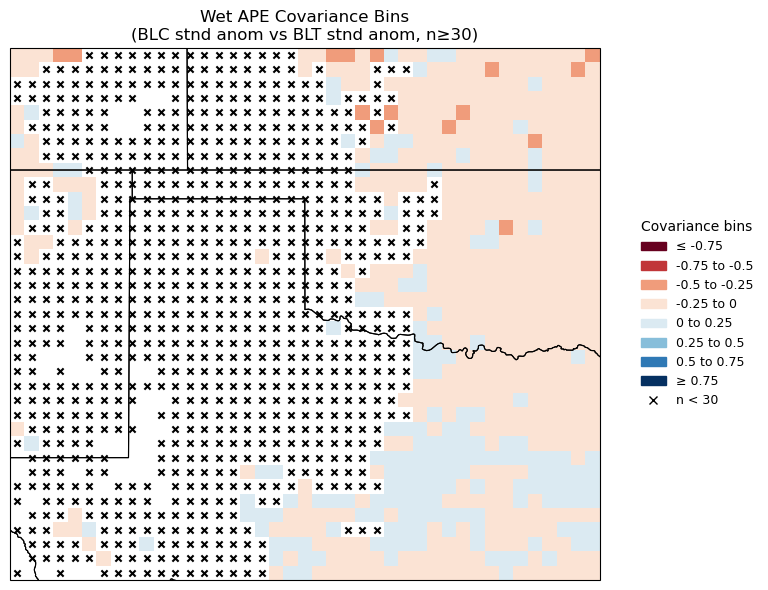

In [27]:
# --- User settings ---
dataset_type = "wet"  # or "wet"

var_x = "blc_stnd_anom"

var_y = "blt_stnd_anom"

# --- Pretty display names for plotting ---
pretty_names = {
    "blc": "BLC",
    "blc_stnd_anom": "BLC stnd anom",
    "blt_stnd_anom": "BLT stnd anom",
    "blt": "BLT",
    "bottom_2km_q": "Bottom 2km q",
    "bottom_1km_q": "Bottom 1km q"
}

# --- Select dataset dynamically ---
data = dry if dataset_type == "dry" else wet

# --- Compute covariance per grid point ---
def cov_xy(x):
    if len(x) < 30:
        return pd.Series([np.nan], index=["cov"])
    cov = x[var_x].cov(x[var_y])
    return pd.Series([cov], index=["cov"])

cov_df = data.groupby(["latitude", "longitude"]).apply(cov_xy, include_groups=False).reset_index()

# --- Define fixed bins matching correlation plot ---
bins = [-1.0, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1.0]
labels = ["≤ -0.75", "-0.75 to -0.5", "-0.5 to -0.25", "-0.25 to 0",
          "0 to 0.25", "0.25 to 0.5", "0.5 to 0.75", "≥ 0.75"]

# --- Bin the covariance values ---
cov_df["cov_bin"] = pd.cut(cov_df["cov"], bins=bins, labels=labels, include_lowest=True)

# --- Pivot for plotting ---
grid_bin = cov_df.pivot(index="latitude", columns="longitude", values="cov_bin")
grid_bin_num = grid_bin.replace({label: i for i, label in enumerate(labels)}).astype(float)

# --- Discrete colormap and norm ---
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

cmap = ListedColormap(plt.cm.RdBu(np.linspace(0, 1, len(labels))))
norm = BoundaryNorm(range(len(labels)+1), cmap.N)

# --- Plot with Cartopy ---
fig, ax = plt.subplots(figsize=(10,6), subplot_kw={"projection": ccrs.PlateCarree()})

im = ax.pcolormesh(
    grid_bin_num.columns, grid_bin_num.index, grid_bin_num.values,
    cmap=cmap, norm=norm, transform=ccrs.PlateCarree()
)

ax.add_feature(cfeature.STATES, linewidth=0.8)
ax.coastlines(resolution="10m", linewidth=0.8)

# --- Overlay symbols for data quality ---
sample_counts = data.groupby(["latitude", "longitude"]).size().reset_index(name="n")
cov_df = cov_df.merge(sample_counts, on=["latitude", "longitude"], how="left")

mask_few = cov_df["n"] < 30
ax.scatter(
    cov_df.loc[mask_few, "longitude"],
    cov_df.loc[mask_few, "latitude"],
    s=20, marker="x", color="black",
    transform=ccrs.PlateCarree(),
    label="n < 30"
)

# --- Create legend ---
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

handles_bins = [Patch(color=cmap(i/(len(labels)-1)), label=label) for i,label in enumerate(labels)]
handles_symbols = [Line2D([0],[0], marker="x", color="black", linestyle="None", markersize=6, label="n < 30")]
handles_all = handles_bins + handles_symbols

ax.legend(handles=handles_all, title="Covariance bins", loc="center left",
          bbox_to_anchor=(1.05,0.5), fontsize=9, frameon=False)

# --- Title and layout ---
title_x = pretty_names.get(var_x, var_x)
title_y = pretty_names.get(var_y, var_y)
plt.title(f"{dataset_type.capitalize()} APE Covariance Bins\n({title_x} vs {title_y}, n≥30)")

plt.tight_layout(rect=[0,0,0.85,1])
plt.show()


In [32]:
# # interpolation of temperature 

# num_levels = 201 # equivalent to 4000 meters AGL for every gridpoint

# num_times = times.shape[0]

# interpolated_t = np.full((num_times, num_levels, lats.shape[0], lons.shape[0]), np.nan)

# for tidx in range(times.shape[0]):
    
#     print(times[tidx])

#     for latidx in range(lats.shape[0]):

#         for lonidx in range(lons.shape[0]):
            
#             t_array = t[tidx, :, latidx, lonidx]

#             alt_array = z[tidx, :, latidx, lonidx]

#             sfc_alt = surface_altitudes[tidx, latidx, lonidx]

#             new_t = interpolate_var_to_altitude(t_array, alt_array, sfc_alt)

#             interpolated_t[tidx, :, latidx, lonidx] = new_t

In [33]:
# # creation of q_fit profiles -> for every gridpoint and everyday, calculate the 0-1km ("mixed layer") average q

# # the collection of all these average qs across time for each gridpoint is the xinput to the regression

# # then, for each height, collect all q values for all times -> this is your y_target

# # the lr model is trained on x input and y input and returns a prediction for q values at that height

# # note that q_fit is equivalent to original q profiles below 2km

# interpolated_altitudes = np.arange(0, 4000 + 20, 20)  

# n_times = interpolated_q.shape[0]  

# n_altitudes = len(interpolated_altitudes) 

# n_lats = lats.shape[0]  

# n_lons = lons.shape[0]  

# interpolated_qfit = np.full((n_times, n_altitudes, n_lats, n_lons), np.nan, dtype=np.float32)

# for latidx in range(n_lats):
    
#     for lonidx in range(n_lons):
        
#         print(lats[latidx], lons[lonidx])
        
#         # extracts all q profiles for a given gridpoint across time series 
        
#         q_array = interpolated_q[:, :, latidx, lonidx]  # shape (time, levels)
        
#         # define indices for bottom 1km and 2km
        
#         bottom_1km_idx = interpolated_altitudes <= 1000
        
#         bottom_2km_idx = interpolated_altitudes <= 2000
        
#         target_idx = (interpolated_altitudes > 2000) & (interpolated_altitudes <= 4000)  # heights to predict

#         # compute near-surface q (mean of bottom 1km for every profile in time series)
        
#         near_surface_q = np.mean(q_array[:, bottom_1km_idx], axis=1).reshape(-1, 1) # shape = (time)

#         lr = LinearRegression()

#         # copy q_array and retain observed values up to 2km
        
#         q_fit = q_array.copy()
        
#         q_fit[:, ~bottom_2km_idx] = np.nan  # Keep observed q below 2km

#         # loop over target heights (above 2km) and perform regression
        
#         for j, idx in enumerate(np.where(target_idx)[0]):
            
#             y_target = q_array[:, idx].reshape(-1, 1)  # Shape (2754, 1)
            
#             # train regression model
            
#             lr.fit(near_surface_q, y_target)
            
#             # Predict q_fit values for this height and assign them to the large array
            
#             q_fit[:, idx] = lr.predict(near_surface_q).flatten()

#         # append the q_fit for this lat, lon position into the big array
        
#         interpolated_qfit[:, :, latidx, lonidx] = q_fit

# print(interpolated_qfit.shape)


In [34]:
# # Step 1: Define the backup directory in your home folder

# backup_dir = os.path.expanduser("~/backup_data")  # Expands ~ to full home directory path

# os.makedirs(backup_dir, exist_ok=True)  # create the directory if it doesn't exist

# # Step 3: Save multiple arrays in a compressed file
# file_path = os.path.join(backup_dir, "backup_arrays_for_buoyancy.npz")  # Full path to save file

# np.savez_compressed(file_path, array1=interpolated_pressure, array2=interpolated_q, array3=interpolated_t,
#                    array_4=interpolated_qfit)

# print(f"Arrays saved to {file_path}")

# # Step 4: Verify that the file exists
# print("Saved files:", os.listdir(backup_dir))

In [35]:
# backup_dir = os.path.expanduser("~/backup_data")

# os.makedirs(backup_dir, exist_ok=True)  # Ensure the directory exists

# file_path = os.path.join(backup_dir, "backup_metadata_for_buoyancy.npz")

# np.savez(file_path, 
#          times=times, 
#          lats=lats, 
#          lons=lons, 
#         )

# print(f"Backup saved at {file_path}")

In [36]:
# # Step 1: Define the backup directory in your home folder
# backup_dir = os.path.expanduser("~/backup_data")  # Expands ~ to full home directory path

# os.makedirs(backup_dir, exist_ok=True)  # create the directory if it doesn't exist

# # Step 3: Save multiple arrays in a compressed file
# file_path = os.path.join(backup_dir, "backup_arrays_for_buoyancy.npz")  # Full path to save file

# # Step 5: Load back the saved arrays
# data = np.load(file_path)  # Load the .npz file

# interpolated_pressure = data['array1']

# print("interpolated_pressure loaded")

# interpolated_q = data['array2']

# print("interpolated_pressure loaded")

# interpolated_t = data['array3']

# print("interpolated_t loaded")

# interpolated_qfit = data['array_4']

# print("interpolated_qfit loaded")

# print("")

# print("Arrays successfully loaded!")

## complete buoyancy script

In [37]:
# backup_dir = os.path.expanduser("~/backup_data")  # Expands ~ to full home directory path

# os.makedirs(backup_dir, exist_ok=True)  # create the directory if it doesn't exist

# file_path = os.path.join(backup_dir, "backup_arrays_for_buoyancy.npz")  # Full path to save file

# # Step 5: Load back the saved arrays
# data = np.load(file_path)  # Load the .npz file

# interpolated_pressure = data['array1']

# print("interpolated_pressure loaded")

# interpolated_q = data['array2']

# print("interpolated_pressure loaded")

# interpolated_t = data['array3']

# print("interpolated_t loaded")

# interpolated_qfit = data['array_4']

# print("interpolated_qfit loaded")

# print("")

# print("Arrays successfully loaded!")

# %run /home/annierosen16/func.ipynb

# all_blt = np.full((times.shape[0], lats.size, lons.size), np.nan)  # Shape (times, lats, lons)

# all_blc = np.full((times.shape[0], lats.size, lons.size), np.nan)  # Shape (times, lats, lons)

# alt = interpolated_altitudes

# g = 9.80665  # m/s^2

# # Loop over all latitudes and longitudes
# for latidx in range(lats.size):
    
#     for lonidx in range(lons.size):
        
#         for tidx in range(times.shape[0]):
            
#             p = interpolated_pressure[tidx, :, latidx, lonidx]
            
#             t = interpolated_t[tidx, :, latidx, lonidx]
            
#             qlc = interpolated_qfit[tidx, :, latidx, lonidx]
            
#             qr = interpolated_q[tidx, :, latidx, lonidx]

#             # Calculate buoyancy
#             b_qr = cal_buoyancy(t_profile=t, h_profile=qr, p_profile=p, alt_profile=alt)
            
#             b_qlc = cal_buoyancy(t_profile=t, h_profile=qlc, p_profile=p, alt_profile=alt)

#             # Convert to Kelvin and calculate y_qr, y_qlc
#             pprof_qr = (b_qr.tp) * units.degK
            
#             pprof_qlc = (b_qlc.tp) * units.degK

#             t = t * units.degC
            
#             t = t.to(units.degK)

#             y_qr = pprof_qr - t
#             y_qlc = pprof_qlc - t

#             # Pressure levels for masks
#             pres_100 = p[0] - 100
            
#             pres_300 = p[0] - 300
            
#             pres_mask = (p >= pres_300) & (p <= pres_100)
            
#             altmask = (alt >= 2000) & (alt <= 4000)

#             x_clipped = p[altmask]
            
#             y_clipped_qr = y_qr[altmask]
            
#             y_clipped_qlc = y_qlc[altmask]

#             # Compute blc, blt
#             br = (mpconsts.Rd * (np.trapz(y_clipped_qr[::-1], np.log(x_clipped[::-1])))).to(units('J/kg'))
            
#             blc = (mpconsts.Rd * (np.trapz(y_clipped_qlc[::-1], np.log(x_clipped[::-1])))).to(units('J/kg'))

#             blt = br - blc

#             all_blt[tidx, latidx, lonidx] = blt.magnitude
            
#             all_blc[tidx, latidx, lonidx] = blc.magnitude

#             print(f"Time index {tidx}, Latitude index {latidx}, Longitude index {lonidx}: blt={blt.magnitude}, blc={blc.magnitude}")



In [38]:
# with open('all_blc.pkl', 'wb') as file:

#     pickle.dump(all_blc, file)

# with open('all_blt.pkl', 'wb') as file:

#     pickle.dump(all_blt, file)   

In [39]:
# # testing on one gridpoint

# interpolated_altitudes = np.arange(0, 4000 + 20, 20)  

# %run /home/annierosen16/func.ipynb

# all_blt = []

# all_blc = []

# g = 9.80665 # m/s^2

# # latidx = np.where(lats == 36.5)[0][0]

# # lonidx = np.where(lons == -97.5)[0][0]

# latidx = 0

# lonidx = 0

# for tidx in range(times.shape[0]):

#     alt = interpolated_altitudes

#     p = interpolated_pressure[tidx, :, latidx, lonidx]

#     t = interpolated_t[tidx, :, latidx, lonidx]

#     qlc = interpolated_qfit[tidx, :, latidx, lonidx]

#     qr = interpolated_q[tidx, :, latidx, lonidx]

#     b_qr = cal_buoyancy(t_profile = t,         
#                             h_profile = qr,         
#                             p_profile = p,        
#                             alt_profile = alt,
#                             )

#     b_qlc = cal_buoyancy(t_profile = t,         
#                         h_profile = qlc,         
#                         p_profile = p,        
#                         alt_profile = alt,
#                         )

#     pprof_qr = (b_qr.tp)*units.degK

#     pprof_qlc = (b_qlc.tp)*units.degK

#     t = t*units.degC

#     t = t.to(units.degK)

#     y_qr = pprof_qr - t

#     y_qlc = pprof_qlc - t

#     pres_100 = p[0]-100

#     pres_300 = p[0]-300

#     pres_mask = (p >= pres_300) & (p <= pres_100)

#     altmask = (alt >= 2000) & (alt <= 4000)

#     x_clipped = p[altmask]

#     y_clipped_qr = y_qr[altmask]

#     y_clipped_qlc = y_qlc[altmask]

#     br = (mpconsts.Rd*(np.trapz(y_clipped_qr[::-1], np.log(x_clipped[::-1])))).to(units('J/kg'))

#     blc = (mpconsts.Rd*(np.trapz(y_clipped_qlc[::-1], np.log(x_clipped[::-1])))).to(units('J/kg'))

#     blt = br - blc

#     all_blt.append(blt.magnitude)
    
#     all_blc.append(blc.magnitude)

#     print(tidx, blt.magnitude, blc.magnitude)